# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习课程设计
- 设计题目：基于 EfficientNet-MLP 融合网络与 RAG-Agent 的皮肤病变多模态智能诊断系统
- 姓名：刘宇广
- 学号：20234080106
- 班级：
- 指导教师：
- 提交日期：2026 年 6 月

本 notebook 为课程设计最终提交报告，内容包括问题定义、数据分析、预处理、模型设计、实验结果、可解释性分析和 RAG-Agent 辅助诊断示例。代码实现主要封装在 `src` 目录中，报告中的统计数据、训练指标、可视化图和诊断示例均由本 notebook 运行结果直接生成。


## 二、摘要

皮肤癌早期筛查对降低疾病风险和提升治疗效果具有重要意义。针对单一图像识别难以充分利用临床背景信息的问题，本课设基于 PAD-UFES-20 数据集设计并实现了一个皮肤病变多模态智能诊断系统。数据集包含 2298 张皮肤病变图像、1373 名患者和 1641 个病灶，诊断类别包括 `ACK / BCC / MEL / NEV / SCC / SEK` 六类。本项目将 `BCC / SCC / MEL` 定义为皮肤癌高风险类别，将 `ACK / SEK / NEV` 定义为非皮肤癌类别，先完成皮肤癌风险二分类，再进行六分类细粒度识别。

模型方面，图像分支采用 EfficientNet-B0 提取病变视觉特征，表格分支采用 MLP 处理年龄、病变直径、性别、病变部位、皮肤类型和病史等临床特征，并通过特征拼接实现多模态融合。实验在正式训练模式下运行 50 个 epoch，测试集规模为 345 条样本。二分类实验中，表格 MLP baseline 的 Accuracy、F1 和 AUC 分别为 94.49%、94.29% 和 97.61%；EfficientNet-MLP 融合模型的 Accuracy、F1 和 AUC 分别为 92.17%、92.08% 和 96.83%，其中皮肤癌 Recall 达到 95.73%。六分类融合模型取得 73.62% Accuracy、73.92% Macro F1 和 95.50% Macro AUC。为提升系统可解释性，本项目进一步引入 Grad-CAM、SHAP 和本地 RAG-Agent，将模型预测、关键特征解释和医学知识检索结果整合为结构化辅助诊断报告。


## 三、问题定义与需求分析

### 3.1 项目背景与意义

皮肤病变类型较多，部分恶性病变在早期外观上与良性病变相似，仅依赖人工观察容易受到医生经验、拍摄条件和就诊资源的影响。深度学习模型能够从图像中学习颜色、边界、纹理和形态等视觉特征，而患者年龄、性别、病变部位、皮肤类型、病变直径、既往病史和症状变化等临床表格信息也能提供重要诊断线索。因此，本课设以多模态融合为核心思路，构建面向皮肤癌辅助筛查的智能诊断系统。

本项目的实际意义主要体现在三点：第一，利用图像和临床信息共同建模，更接近真实医疗场景中的诊断流程；第二，通过二分类风险筛查降低高风险皮肤癌样本漏检概率；第三，通过 Grad-CAM、SHAP 与 RAG-Agent 输出可解释报告，使模型结果更便于课程展示和人工复核。

### 3.2 问题描述

系统输入包括一张皮肤病变 PNG 图像和同一病灶对应的临床表格特征。输出分为两个阶段：

1. **皮肤癌风险二分类**：输出 `0 = 非皮肤癌`、`1 = 皮肤癌高风险` 及对应概率，其中 `BCC / SCC / MEL` 归为皮肤癌，`ACK / SEK / NEV` 归为非皮肤癌。
2. **六分类细粒度识别**：输出 `ACK / BCC / MEL / NEV / SCC / SEK` 六类概率，用于进一步说明最可能的具体病变类型。

除分类性能外，系统还需要满足可解释和报告生成需求。图像侧使用 Grad-CAM 展示模型关注区域，表格侧使用 SHAP 分析特征贡献，RAG-Agent 根据预测结果、模型解释和本地医学知识库生成辅助诊断文本。评价指标方面，二分类重点关注 Accuracy、Precision、Recall、F1-score、AUC 和混淆矩阵；其中 Recall 与 F1-score 对筛查任务更关键。六分类阶段重点关注 Accuracy、Macro Precision、Macro Recall、Macro F1、Macro AUC 和六分类混淆矩阵，以评估模型对少数类和易混淆类别的识别能力。


## 四、数据集说明与预处理

### 4.1 数据来源与规模

本项目使用 PAD-UFES-20 数据集，数据位于 `data` 目录，包含 `metadata.csv` 和三部分图像文件夹。该数据集同时提供皮肤病变临床图像和患者临床表格信息，适合开展图像 + 表格的多模态深度学习实验。

本次本地读取后的有效数据规模为 2298 张图像、1373 名患者、1641 个病灶。六分类样本分布为：`BCC` 845、`ACK` 730、`NEV` 244、`SEK` 235、`SCC` 192、`MEL` 52。二分类标签中，非皮肤癌样本 1209 条，皮肤癌高风险样本 1089 条，整体相对均衡；但六分类内部差异明显，`BCC` 和 `ACK` 样本较多，`MEL` 仅 52 条，是典型少数类。

下面通过代码读取本地数据并输出真实统计结果，后续所有实验均基于该清洗后的数据表进行。


In [1]:
import importlib
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 若修改过 src 脚本后未重启内核，先清除旧缓存再导入
for mod_name in list(sys.modules):
    if mod_name == "src" or mod_name.startswith("src."):
        del sys.modules[mod_name]

try:
    import torch
    import torchvision
    TORCH_READY = True
except ImportError as exc:
    TORCH_READY = False
    print("当前环境缺少 PyTorch，请先运行：pip install -r requirements.txt")
    print(exc)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import DISEASE_CLASSES, FIGURE_DIR, MODEL_DIR, ensure_output_dirs
from src.data_utils import (
    build_tabular_preprocessor,
    dataset_summary,
    get_available_features,
    prepare_dataframe,
    split_dataframe,
)
from src.visualize import plot_class_distribution, plot_correlation_analysis, show_sample_images

ensure_output_dirs()
df = prepare_dataframe()
summary = dataset_summary(df)

print(f"Python: {sys.version.split()[0]}")
if TORCH_READY:
    print(f"PyTorch: {torch.__version__}")
    print(f"Torchvision: {torchvision.__version__}")
    print(f"CUDA 可用: {torch.cuda.is_available()}")

print("\n数据集统计：")
for key, value in summary.items():
    print(f"{key}: {value}")

df[["patient_id", "lesion_id", "img_id", "diagnostic", "binary_label", "image_path"]].head()

Python: 3.10.0
PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA 可用: True

数据集统计：
num_images: 2298
num_patients: 1373
num_lesions: 1641
diagnostic_counts: {'BCC': 845, 'ACK': 730, 'NEV': 244, 'SEK': 235, 'SCC': 192, 'MEL': 52}
binary_counts: {0: 1209, 1: 1089}


,patient_id,lesion_id,img_id,diagnostic,binary_label,image_path
0,PAT_1516,1765,PAT_1516_1765_530.png,NEV,0,E:\BDC_DL\data\imgs_part_3\imgs_part_3\PAT_151...
1,PAT_46,881,PAT_46_881_939.png,BCC,1,E:\BDC_DL\data\imgs_part_1\imgs_part_1\PAT_46_...
2,PAT_1545,1867,PAT_1545_1867_547.png,ACK,0,E:\BDC_DL\data\imgs_part_3\imgs_part_3\PAT_154...
3,PAT_1989,4061,PAT_1989_4061_934.png,ACK,0,E:\BDC_DL\data\imgs_part_3\imgs_part_3\PAT_198...
4,PAT_684,1302,PAT_684_1302_588.png,BCC,1,E:\BDC_DL\data\imgs_part_2\imgs_part_2\PAT_684...


### 4.2 数据可视化与分析

本节从类别分布、样本图像和临床特征相关性三个角度分析 PAD-UFES-20 数据集。可视化结果用于确认两个关键问题：一是六分类任务存在明显类别不平衡，二是临床表格特征与皮肤癌风险之间具有可利用的信息，因此后续模型需要同时考虑类别权重、分层划分、图像增强和表格特征编码。


#### 4.2.1 统计分布

六分类分布显示，`BCC` 和 `ACK` 是主要类别，`MEL` 样本显著偏少，仅占全部样本约 2.26%。这种不平衡会导致模型更容易学习多数类，因此训练中使用按类别加权的交叉熵损失，并在划分训练集、验证集和测试集时按六分类标签进行分层抽样。二分类分布为 1209:1089，整体接近均衡，适合作为第一阶段皮肤癌风险筛查任务。


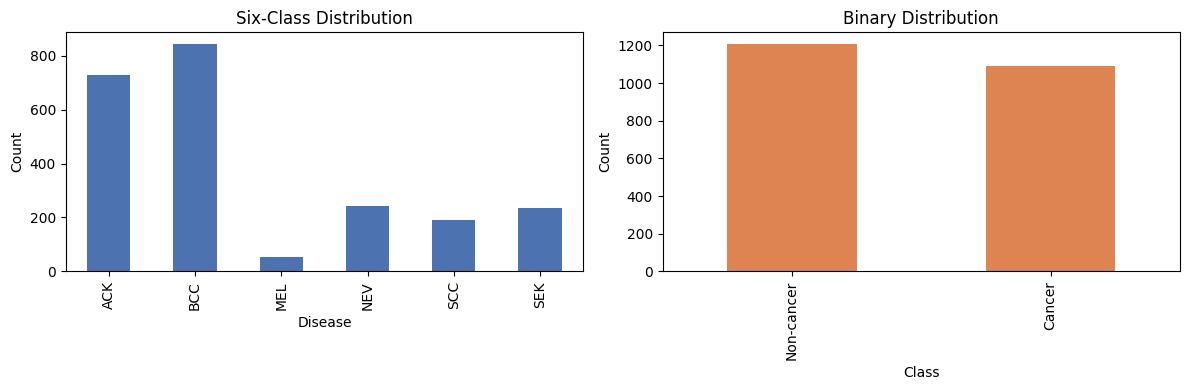

In [2]:
plot_class_distribution(df, save_path=FIGURE_DIR / "class_distribution.png");

#### 4.2.2 样本示例

样本图像展示了六类皮肤病变在颜色、边界、纹理和病灶形态上的差异。由于同一类别内部也存在较大视觉差异，单纯依赖图像会受到拍摄角度、光照、病灶尺度和背景皮肤区域的影响；这也是本项目引入年龄、病变部位、直径、皮肤类型和病史等临床表格信息的重要原因。


e:\BDC_DL\src\visualize.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(min(n_per_class, len(group)), random_state=42))


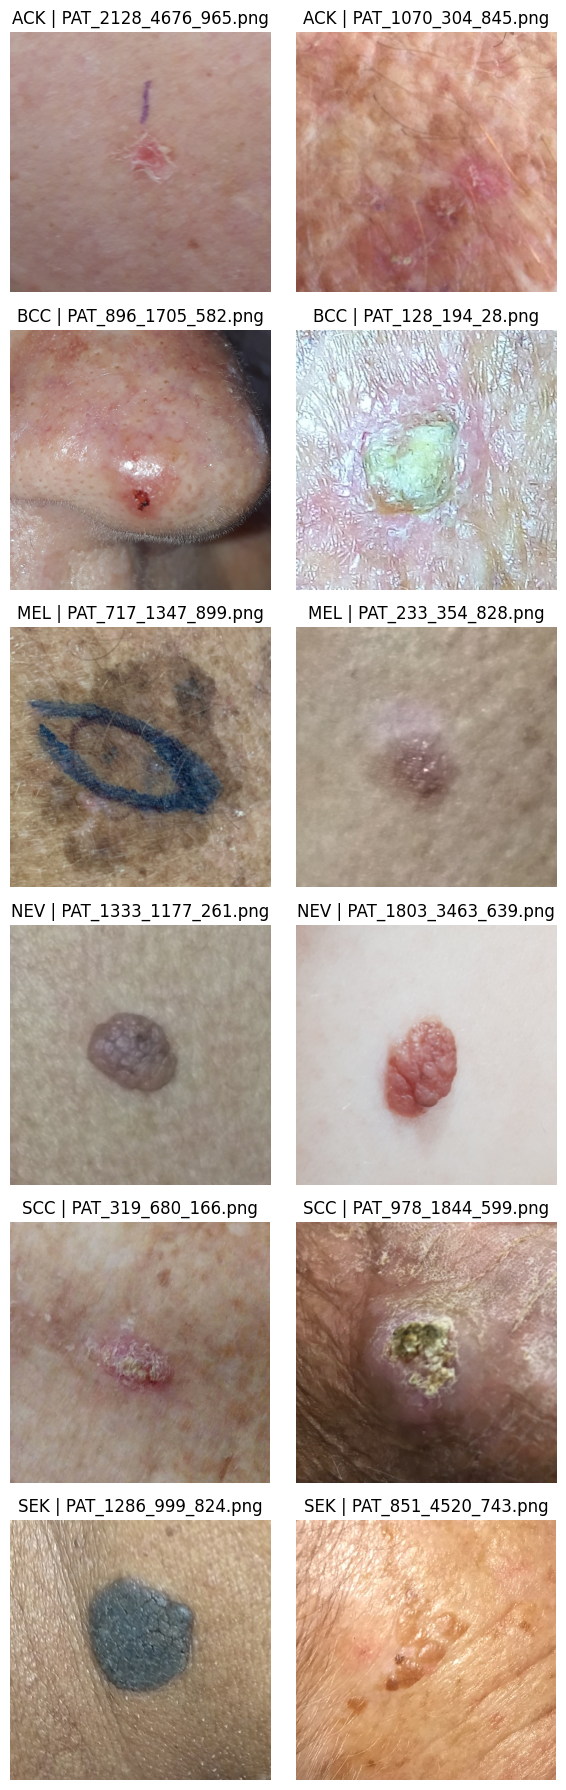

In [3]:
show_sample_images(df, n_per_class=2, save_path=FIGURE_DIR / "sample_images.png");

#### 4.2.3 相关性分析

PAD-UFES-20 的临床表格字段存在一定缺失，其中 `background_mother`、`background_father`、`smoke`、`fitspatrick`、`diameter_1` 等字段缺失率约为 35%。因此，相关性分析主要用于辅助理解数据，而不是直接作为结论。代码中分别绘制数值特征 Pearson 相关、数值特征与二分类标签的关联，以及类别特征与皮肤癌风险的 Cramer's V 关联度，为后续特征填充、标准化和类别编码提供依据。


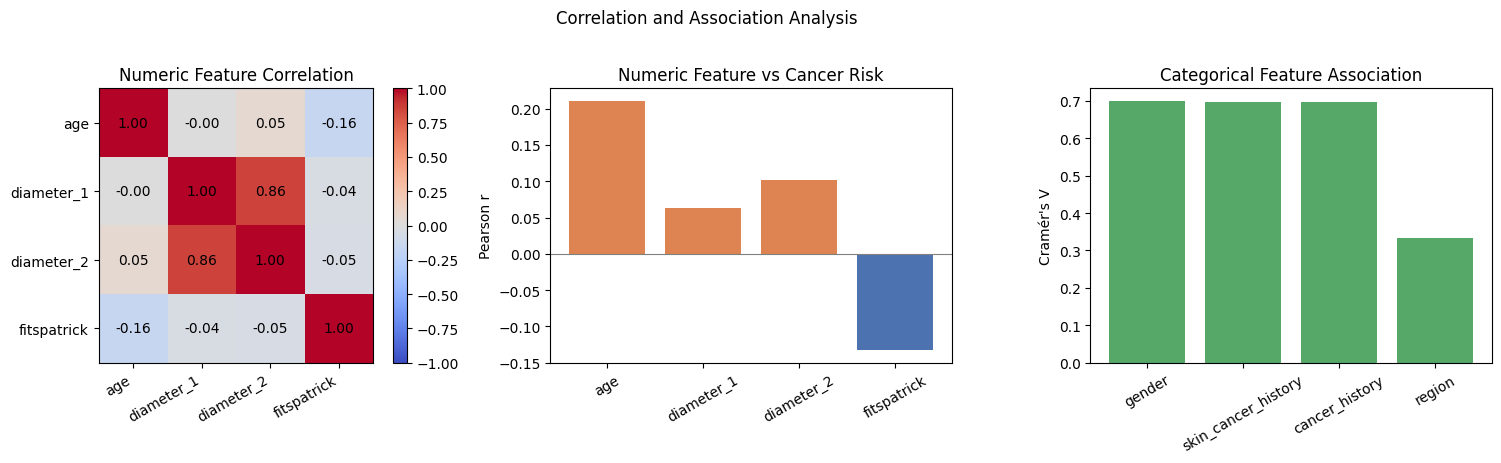

In [4]:
import importlib
import sys

if "src.visualize" in sys.modules:
    del sys.modules["src.visualize"]

from src.visualize import plot_correlation_analysis

plot_correlation_analysis(
    df,
    categorical_features=["gender", "region", "skin_cancer_history", "cancer_history"],
    save_path=FIGURE_DIR / "correlation_analysis.png",
);

### 4.3 预处理流程

本项目预处理流程包括数据清洗、标签构造、特征编码、图像增强和数据集划分五个步骤：

1. **清洗**：保留 6 类有效诊断标签，递归匹配图像路径，剔除无法匹配的样本；最终有效样本数为 2298。
2. **标注**：将 `diagnostic` 映射为二分类标签 `binary_label`，其中 `BCC / SCC / MEL = 1`，`ACK / SEK / NEV = 0`；同时构造六分类标签 `multiclass_label`。
3. **表格处理**：数值特征包括 `age`、`diameter_1`、`diameter_2`、`fitspatrick`，使用中位数填充后标准化；类别特征共 18 个，经过编码后表格特征维度为 78。
4. **图像处理**：训练阶段使用 `224 x 224` 缩放、随机水平翻转、随机旋转、亮度/对比度扰动和 ImageNet 均值方差归一化；验证集和测试集只进行缩放、张量转换和归一化。
5. **数据划分**：按六分类标签分层划分训练集、验证集和测试集，比例为 70% / 15% / 15%，对应样本数为 1608 / 345 / 345。

下面的代码单元展示了缺失率、标签映射、划分结果、编码维度和图像变换配置。


In [5]:
numeric_features, categorical_features = get_available_features(df)
feature_cols = numeric_features + categorical_features

# 1. 清洗：统计缺失值，确认图像-表格样本已对齐
missing_rate = df[feature_cols].isna().mean().sort_values(ascending=False)
print("【清洗】有效样本数:", len(df))
print("【清洗】缺失率较高的字段（前 5 项）:")
print(missing_rate.head())

# 2. 标注：展示二分类与六分类标签映射
label_map = df[["diagnostic", "binary_label", "multiclass_label"]].drop_duplicates().sort_values("multiclass_label")
print("\n【标注】疾病类别与标签映射:")
print(label_map.to_string(index=False))

# 3. 划分 + 表格归一化/编码
train_df, val_df, test_df = split_dataframe(df, label_col="multiclass_label")

preprocessor = build_tabular_preprocessor(numeric_features, categorical_features)
X_train_tab = preprocessor.fit_transform(train_df[feature_cols])
X_val_tab = preprocessor.transform(val_df[feature_cols])
X_test_tab = preprocessor.transform(test_df[feature_cols])

try:
    tabular_feature_names = list(preprocessor.get_feature_names_out())
except Exception:
    tabular_feature_names = [f"feature_{i}" for i in range(X_train_tab.shape[1])]

print("\n【划分】训练集:", train_df.shape, "验证集:", val_df.shape, "测试集:", test_df.shape)
print("【归一化】数值特征:", numeric_features)
print("【归一化/编码】类别特征数量:", len(categorical_features))
print("【归一化/编码】编码后表格特征维度:", X_train_tab.shape[1])

# 4. 数据增强与图像归一化配置
if TORCH_READY:
    from src.train import build_transforms

    train_tfms, eval_tfms = build_transforms()
    print("\n【数据增强】训练集变换:")
    print(train_tfms)
    print("\n【归一化】验证/测试集变换:")
    print(eval_tfms)
else:
    print("\n【数据增强/归一化】当前环境未检测到 PyTorch，图像增强配置将在模型训练单元中加载。")

【清洗】有效样本数: 2298
【清洗】缺失率较高的字段（前 5 项）:
background_mother    0.357702
background_father    0.355962
smoke                0.349869
fitspatrick          0.349869
diameter_1           0.349869
dtype: float64

【标注】疾病类别与标签映射:
diagnostic  binary_label  multiclass_label
       ACK             0                 0
       BCC             1                 1
       MEL             1                 2
       NEV             0                 3
       SCC             1                 4
       SEK             0                 5

【划分】训练集: (1608, 29) 验证集: (345, 29) 测试集: (345, 29)
【归一化】数值特征: ['age', 'diameter_1', 'diameter_2', 'fitspatrick']
【归一化/编码】类别特征数量: 18
【归一化/编码】编码后表格特征维度: 78

【数据增强】训练集变换:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
    ToTenso

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

为了判断不同模态对任务的贡献，本项目设置两类 baseline：

1. **Tabular-MLP Baseline**：只使用患者临床表格特征，不读取图像，用于评估年龄、病变直径、病变部位、皮肤类型和病史等临床信息本身的分类能力。
2. **EfficientNet-B0 Image Baseline**：只使用皮肤病变图像，不使用表格特征，用于评估图像模态单独完成皮肤癌风险筛查的能力。

随后将二者与 EfficientNet-MLP 融合模型进行对比，从 Accuracy、Recall、F1 和 AUC 等指标分析图像、表格及融合后的性能差异。

### 5.2 最终模型架构

最终模型为 EfficientNet-MLP 多模态融合网络。图像分支使用 EfficientNet-B0 提取高维视觉特征，表格分支使用 MLP 将编码后的临床特征映射到隐空间，融合层将两类特征拼接后输入分类器输出 logits。二分类阶段分类头输出 2 个节点，用于判断皮肤癌风险；六分类阶段分类头输出 6 个节点，用于识别 `ACK / BCC / MEL / NEV / SCC / SEK`。

```text
Image Feature = EfficientNet-B0(image)
Tabular Feature = MLP(tabular_data)
Fusion Feature = Concat(Image Feature, Tabular Feature)
Prediction = Classifier(Fusion Feature)
```

这种结构的优点是实现清晰、可与单模态 baseline 直接比较，并且便于在后续加入预训练、注意力融合或门控融合机制。下面调用 `src.models` 构建两类 baseline、二分类融合模型和六分类融合模型，并调用 `src.datasets`、`src.train` 完成训练数据加载。


In [6]:
if TORCH_READY:
    import importlib

    for mod_name in list(sys.modules):
        if mod_name in {"src.models", "src.datasets", "src.train", "src.visualize"}:
            del sys.modules[mod_name]

    from src.datasets import SkinLesionDataset
    import src.models as models_module
    importlib.reload(models_module)
    from src.models import EfficientNetMLPFusion, ImageBaseline, TabularBaseline
    from src.train import (
        build_transforms,
        compute_class_weights,
        evaluate,
        fit_model,
        get_device,
        make_dataloader,
    )
    from src.visualize import plot_confusion_matrix, plot_training_history

    QUICK_RUN = False  # 正式实验模式；如只想快速验证流程，可临时改为 True
    EPOCHS = 1 if QUICK_RUN else 50
    BATCH_SIZE = 8 if QUICK_RUN else 16

    def stratified_sample(frame, max_rows, label_col="multiclass_label"):
        if (max_rows is None) or (len(frame) <= max_rows):
            return frame.reset_index(drop=True)
        per_class = max_rows // frame[label_col].nunique()
        return (
            frame.groupby(label_col, group_keys=False)
            .apply(lambda g: g.sample(min(len(g), per_class), random_state=42))
            .reset_index(drop=True)
        )

    train_run_df = stratified_sample(train_df, 180 if QUICK_RUN else None)
    val_run_df = stratified_sample(val_df, 60 if QUICK_RUN else None)
    test_run_df = stratified_sample(test_df, 60 if QUICK_RUN else None)

    X_train_run = preprocessor.transform(train_run_df[feature_cols])
    X_val_run = preprocessor.transform(val_run_df[feature_cols])
    X_test_run = preprocessor.transform(test_run_df[feature_cols])

    train_tfms, eval_tfms = build_transforms()

    binary_train_dataset = SkinLesionDataset(train_run_df, X_train_run, train_tfms, label_col="binary_label")
    binary_val_dataset = SkinLesionDataset(val_run_df, X_val_run, eval_tfms, label_col="binary_label")
    binary_test_dataset = SkinLesionDataset(test_run_df, X_test_run, eval_tfms, label_col="binary_label")

    six_train_dataset = SkinLesionDataset(train_run_df, X_train_run, train_tfms, label_col="multiclass_label")
    six_val_dataset = SkinLesionDataset(val_run_df, X_val_run, eval_tfms, label_col="multiclass_label")
    six_test_dataset = SkinLesionDataset(test_run_df, X_test_run, eval_tfms, label_col="multiclass_label")

    train_loader = make_dataloader(binary_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = make_dataloader(binary_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = make_dataloader(binary_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    six_train_loader = make_dataloader(six_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    six_val_loader = make_dataloader(six_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    six_test_loader = make_dataloader(six_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = get_device()
    class_weights = compute_class_weights(train_run_df["binary_label"].values, num_classes=2)
    six_class_weights = compute_class_weights(train_run_df["multiclass_label"].values, num_classes=len(DISEASE_CLASSES))

    tabular_baseline = TabularBaseline(tabular_dim=X_train_tab.shape[1], num_classes=2)
    image_baseline = ImageBaseline(num_classes=2, pretrained=False, freeze_backbone=False)
    fusion_model = EfficientNetMLPFusion(
        tabular_dim=X_train_tab.shape[1],
        num_classes=2,
        pretrained=False,
        freeze_backbone=False,
    )
    six_fusion_model = EfficientNetMLPFusion(
        tabular_dim=X_train_tab.shape[1],
        num_classes=len(DISEASE_CLASSES),
        pretrained=False,
        freeze_backbone=False,
    )

    print(f"运行设备: {device}")
    print(f"正式实验模式 QUICK_RUN={QUICK_RUN}, epoch={EPOCHS}, batch_size={BATCH_SIZE}")
    print(f"训练样本: {len(train_run_df)}, 验证样本: {len(val_run_df)}, 测试样本: {len(test_run_df)}")
    print(f"表格 Baseline: {tabular_baseline.__class__.__name__}")
    print(f"图像 Baseline: {image_baseline.__class__.__name__}, 输出类别数=2")
    print(f"二分类融合模型: {fusion_model.__class__.__name__}, 输出类别数=2")
    print(f"六分类融合模型: {six_fusion_model.__class__.__name__}, 输出类别数={len(DISEASE_CLASSES)}")

运行设备: cuda
正式实验模式 QUICK_RUN=False, epoch=50, batch_size=16
训练样本: 1608, 验证样本: 345, 测试样本: 345
表格 Baseline: TabularBaseline
图像 Baseline: ImageBaseline, 输出类别数=2
二分类融合模型: EfficientNetMLPFusion, 输出类别数=2
六分类融合模型: EfficientNetMLPFusion, 输出类别数=6


## 六、实验与结果分析

### 6.1 实验环境

本 notebook 按教师模板自动检测硬件和软件环境。当前实验在正式模式 `QUICK_RUN=False` 下运行，使用完整训练集、验证集和测试集进行训练与评估。实际运行环境为 Windows 10、Intel i5-10600KF、31.9 GB 内存、NVIDIA GeForce RTX 2060 SUPER 8 GB，软件环境包括 Python 3.10.0、PyTorch 2.5.1+cu121、Torchvision 0.20.1+cu121、NumPy 2.2.6、Pandas 2.3.3 和 scikit-learn 1.6.1。


In [7]:
from src.env_utils import print_experiment_environment

quick_run = globals().get("QUICK_RUN", False)
experiment_env = print_experiment_environment(quick_run=quick_run)

【6.1 实验环境】

硬件环境：
- CPU：Intel(R) Core(TM) i5-10600KF CPU @ 4.10GHz
- 操作系统：Windows-10-10.0.19041-SP0
- 内存：31.9 GB
- GPU 0: NVIDIA GeForce RTX 2060 SUPER (8.0 GB)

软件环境：
- Python：3.10.0
- PyTorch：2.5.1+cu121
- Torchvision：0.20.1+cu121
- NumPy：2.2.6
- Pandas：2.3.3
- scikit-learn：1.6.1
- Matplotlib：3.10.8
- Pillow：12.1.1

运行配置：
- CUDA 可用：True
- CUDA 版本：12.1
- 当前训练设备：cuda
- 实验模式：正式实验模式


### 6.2 评价指标

本项目实验指标由 `src/train.py` 中的 `evaluate()` 调用 scikit-learn 计算。二分类和六分类均报告 Accuracy、Precision、Recall、F1-score、AUC、classification report 和混淆矩阵。

#### 6.2.1 二分类指标（皮肤癌 / 非皮肤癌）

记 TP、FP、TN、FN 分别为真正例、假正例、真负例、假负例，$N=TP+TN+FP+FN$：

| 指标 | 计算公式 | 含义 |
|------|----------|------|
| **Accuracy** | $\mathrm{Acc}=\dfrac{TP+TN}{N}$ | 全部样本中预测正确的比例 |
| **Precision** | $\mathrm{Pre}=\dfrac{TP}{TP+FP}$ | 预测为皮肤癌的样本中，真正为皮肤癌的比例 |
| **Recall** | $\mathrm{Rec}=\dfrac{TP}{TP+FN}$ | 真实皮肤癌样本中被成功检出的比例 |
| **F1-score** | $\mathrm{F1}=\dfrac{2\cdot \mathrm{Pre}\cdot \mathrm{Rec}}{\mathrm{Pre}+\mathrm{Rec}}$ | Precision 与 Recall 的调和平均 |
| **AUC** | ROC 曲线下面积 | 衡量模型对正类概率的排序能力 |
| **Confusion Matrix** | $\begin{bmatrix}TN&FP\\FN&TP\end{bmatrix}$ | 展示非皮肤癌/皮肤癌的误判结构 |

对于皮肤癌辅助筛查，漏检高风险样本的代价通常高于误报，因此 Recall 与 F1-score 比单纯 Accuracy 更能体现筛查价值。

#### 6.2.2 六分类指标（ACK / BCC / MEL / NEV / SCC / SEK）

六分类阶段类别数为 $K=6$。本项目重点关注 Macro Precision、Macro Recall 和 Macro F1，因为 Macro 指标会对每个类别赋予相同权重，能够更真实地反映 `MEL`、`SCC` 等少数类的识别情况。Macro AUC 使用 One-vs-Rest 方式计算各类别 AUC 后取平均，用于衡量模型对多类概率排序的整体质量。

### 6.3 超参数设置与调优

正式实验中图像尺寸设为 `224 x 224`，batch size 为 16，训练轮数为 50，优化器使用 AdamW，损失函数为带类别权重的交叉熵。表格 baseline 学习率为 `1e-3`，图像 baseline 与融合模型学习率为 `1e-4`。类别权重由训练集标签分布自动计算，用于缓解六分类样本不平衡问题。

### 6.4 主要实验结果

本节依次展示表格 MLP Baseline、图像 EfficientNet Baseline、EfficientNet-MLP 二分类融合模型的训练与测试结果，并在 6.4.4 对三类二分类模型进行对比分析；随后给出融合模型训练曲线、混淆矩阵及六分类细粒度识别实验。所有指标均来自 notebook 当前运行输出。


#### 6.4.1 表格 MLP Baseline 实验

表格 MLP baseline 只使用临床表格特征。该实验用于回答：在不使用图像的情况下，患者年龄、病变直径、皮肤类型、病变部位和病史等结构化信息能否完成较可靠的皮肤癌风险筛查。


In [8]:
if TORCH_READY:
    tabular_baseline, tabular_baseline_history = fit_model(
        tabular_baseline,
        train_loader,
        val_loader,
        num_epochs=EPOCHS,
        lr=1e-3,
        class_weights=class_weights,
        device=device,
    )
    torch.save(tabular_baseline.state_dict(), MODEL_DIR / "tabular_baseline.pt")
    tabular_baseline_metrics = evaluate(
        tabular_baseline,
        test_loader,
        torch.nn.CrossEntropyLoss(weight=class_weights.to(device)),
        device,
    )
    print("表格 MLP Baseline 测试集结果：")
    print({k: round(v, 4) for k, v in tabular_baseline_metrics.items() if k in ["accuracy", "precision", "recall", "f1", "auc"]})
    print(tabular_baseline_metrics["classification_report"])

Epoch 1/50 | train_loss=0.3953 val_loss=0.2373 val_acc=0.8870 val_f1=0.8850
Epoch 2/50 | train_loss=0.2258 val_loss=0.2636 val_acc=0.8957 val_f1=0.8882
Epoch 3/50 | train_loss=0.1982 val_loss=0.2160 val_acc=0.8928 val_f1=0.8896
Epoch 4/50 | train_loss=0.1887 val_loss=0.2065 val_acc=0.8957 val_f1=0.8947
Epoch 5/50 | train_loss=0.1701 val_loss=0.2093 val_acc=0.9043 val_f1=0.9027
Epoch 6/50 | train_loss=0.1629 val_loss=0.2039 val_acc=0.9101 val_f1=0.9101
Epoch 7/50 | train_loss=0.1503 val_loss=0.2112 val_acc=0.9101 val_f1=0.9086
Epoch 8/50 | train_loss=0.1386 val_loss=0.2034 val_acc=0.9188 val_f1=0.9172
Epoch 9/50 | train_loss=0.1266 val_loss=0.2077 val_acc=0.9159 val_f1=0.9134
Epoch 10/50 | train_loss=0.1146 val_loss=0.2014 val_acc=0.9072 val_f1=0.9070
Epoch 11/50 | train_loss=0.0994 val_loss=0.2512 val_acc=0.9043 val_f1=0.8991
Epoch 12/50 | train_loss=0.0938 val_loss=0.2251 val_acc=0.9159 val_f1=0.9113
Epoch 13/50 | train_loss=0.0867 val_loss=0.2199 val_acc=0.9130 val_f1=0.9112
Epoch 14

#### 6.4.2 图像 EfficientNet Baseline 实验

图像 baseline 只使用皮肤病变图像，通过 EfficientNet-B0 提取视觉特征。该实验用于衡量当前数据规模和训练配置下图像模态的独立分类能力，并作为多模态融合模型的对照。


In [9]:
if TORCH_READY:
    image_baseline, image_baseline_history = fit_model(
        image_baseline,
        train_loader,
        val_loader,
        num_epochs=EPOCHS,
        lr=1e-4,
        class_weights=class_weights,
        device=device,
    )
    torch.save(image_baseline.state_dict(), MODEL_DIR / "image_baseline.pt")
    image_baseline_metrics = evaluate(
        image_baseline,
        test_loader,
        torch.nn.CrossEntropyLoss(weight=class_weights.to(device)),
        device,
    )
    print("图像 EfficientNet Baseline 测试集结果：")
    print({k: round(v, 4) for k, v in image_baseline_metrics.items() if k in ["accuracy", "precision", "recall", "f1", "auc"]})
    print(image_baseline_metrics["classification_report"])

Epoch 1/50 | train_loss=0.7018 val_loss=0.6812 val_acc=0.5681 val_f1=0.3005
Epoch 2/50 | train_loss=0.6987 val_loss=0.6919 val_acc=0.6029 val_f1=0.4268
Epoch 3/50 | train_loss=0.6787 val_loss=0.6268 val_acc=0.6522 val_f1=0.5714
Epoch 4/50 | train_loss=0.6553 val_loss=0.6109 val_acc=0.6754 val_f1=0.6267
Epoch 5/50 | train_loss=0.6367 val_loss=0.5769 val_acc=0.6754 val_f1=0.6647
Epoch 6/50 | train_loss=0.6201 val_loss=0.5545 val_acc=0.7130 val_f1=0.7027
Epoch 7/50 | train_loss=0.5827 val_loss=0.5897 val_acc=0.7275 val_f1=0.7251
Epoch 8/50 | train_loss=0.5822 val_loss=0.5295 val_acc=0.7420 val_f1=0.7405
Epoch 9/50 | train_loss=0.5642 val_loss=0.5364 val_acc=0.7362 val_f1=0.7300
Epoch 10/50 | train_loss=0.5563 val_loss=0.5380 val_acc=0.7304 val_f1=0.7103
Epoch 11/50 | train_loss=0.5493 val_loss=0.5350 val_acc=0.7391 val_f1=0.7458
Epoch 12/50 | train_loss=0.5380 val_loss=0.5505 val_acc=0.7304 val_f1=0.7029
Epoch 13/50 | train_loss=0.5341 val_loss=0.6412 val_acc=0.6493 val_f1=0.6967
Epoch 14

#### 6.4.3 EfficientNet-MLP 二分类融合实验

在两类 baseline 之后，训练图像 + 表格融合模型完成第一阶段皮肤癌风险二分类。该模型同时利用病变视觉特征和临床背景信息，目标是在保持较高总体性能的同时提高皮肤癌类别的召回率，减少高风险样本漏检。


In [10]:
if TORCH_READY:
    fusion_model, fusion_history = fit_model(
        fusion_model,
        train_loader,
        val_loader,
        num_epochs=EPOCHS,
        lr=1e-4,
        class_weights=class_weights,
        device=device,
    )
    torch.save(fusion_model.state_dict(), MODEL_DIR / "efficientnet_mlp_fusion.pt")
    fusion_metrics = evaluate(
        fusion_model,
        test_loader,
        torch.nn.CrossEntropyLoss(weight=class_weights.to(device)),
        device,
    )
    print("EfficientNet-MLP 融合模型测试集结果：")
    print({k: round(v, 4) for k, v in fusion_metrics.items() if k in ["accuracy", "precision", "recall", "f1", "auc"]})
    print(fusion_metrics["classification_report"])

Epoch 1/50 | train_loss=0.6533 val_loss=0.5307 val_acc=0.8203 val_f1=0.8000
Epoch 2/50 | train_loss=0.4122 val_loss=0.5302 val_acc=0.8754 val_f1=0.8761
Epoch 3/50 | train_loss=0.3007 val_loss=0.3917 val_acc=0.8986 val_f1=0.8986
Epoch 4/50 | train_loss=0.2689 val_loss=0.2494 val_acc=0.8957 val_f1=0.8983
Epoch 5/50 | train_loss=0.2509 val_loss=0.3263 val_acc=0.8899 val_f1=0.8920
Epoch 6/50 | train_loss=0.2440 val_loss=0.2518 val_acc=0.9159 val_f1=0.9155
Epoch 7/50 | train_loss=0.2394 val_loss=0.2265 val_acc=0.9217 val_f1=0.9208
Epoch 8/50 | train_loss=0.2024 val_loss=0.2358 val_acc=0.9043 val_f1=0.9049
Epoch 9/50 | train_loss=0.2228 val_loss=0.2036 val_acc=0.9072 val_f1=0.9086
Epoch 10/50 | train_loss=0.2070 val_loss=0.2506 val_acc=0.9043 val_f1=0.9038
Epoch 11/50 | train_loss=0.2045 val_loss=0.2187 val_acc=0.9101 val_f1=0.9086
Epoch 12/50 | train_loss=0.1979 val_loss=0.2202 val_acc=0.9072 val_f1=0.9075
Epoch 13/50 | train_loss=0.2106 val_loss=0.2249 val_acc=0.9101 val_f1=0.9080
Epoch 14

#### 6.4.4 二分类三模型对比分析

综合 6.4.1-6.4.3 在测试集（345 条样本）上的结果，三类模型的主要指标如下：

| 模型 | Accuracy | Precision | Recall | F1 | AUC |
|------|----------|-----------|--------|-----|-----|
| 表格 MLP Baseline | 94.49% | 92.90% | 95.73% | 94.29% | 97.61% |
| 图像 EfficientNet Baseline | 75.65% | 75.32% | 72.56% | 73.91% | 84.30% |
| EfficientNet-MLP 融合 | 92.17% | 88.70% | 95.73% | 92.08% | 96.83% |

**主要结论如下：**

1. **临床表格信息在本数据集上具有很强判别力。** 表格 MLP baseline 取得最高 Accuracy（94.49%）和 F1（94.29%），说明 PAD-UFES-20 中年龄、直径、病变部位、皮肤类型和病史等字段与皮肤癌风险高度相关。

2. **纯图像 baseline 表现相对较弱。** 图像 EfficientNet baseline 的 Accuracy 为 75.65%、F1 为 73.91%、AUC 为 84.30%，明显低于表格模型和融合模型。可能原因包括数据规模有限、类别不平衡、皮肤病变图像内部差异大，以及当前训练配置下图像分支没有充分利用大规模预训练知识。

3. **融合模型显著优于纯图像模型，但未超过表格 baseline。** 融合模型相比图像 baseline 的 Accuracy 提升 16.52 个百分点，F1 提升 18.17 个百分点，说明临床表格特征有效补足了图像特征不足。但融合模型比表格 baseline 的 Accuracy 低 2.32 个百分点，表明简单拼接融合尚未完全释放图像模态增益。

4. **融合模型仍具有筛查价值。** 融合模型皮肤癌 Recall 为 95.73%，与表格 baseline 持平，高于图像 baseline 的 72.56%。按测试集支持数估算，融合模型对 164 个皮肤癌样本检出约 157 个，漏检约 7 个，适合作为高召回筛查模型进一步优化。

5. **后续改进方向。** 可尝试 ImageNet 预训练、按验证集 F1 保存最优 checkpoint、冻结/解冻分阶段训练、分模态学习率、门控融合或注意力融合，以提高图像特征质量并减少融合后对表格模态的依赖。


#### 6.4.5 二分类训练曲线与混淆矩阵

下面展示二分类融合模型训练曲线和测试集混淆矩阵。训练曲线显示模型在前若干 epoch 快速收敛，后期验证指标在较高水平附近波动；测试集混淆矩阵用于观察非皮肤癌与皮肤癌之间的误判结构。根据测试集指标估算，融合模型在 164 个皮肤癌样本中召回约 157 个，漏检约 7 个；在 181 个非皮肤癌样本中约有 20 个被误报为皮肤癌。该误判结构符合辅助筛查任务“宁可适度误报，也要尽量减少漏检”的目标。


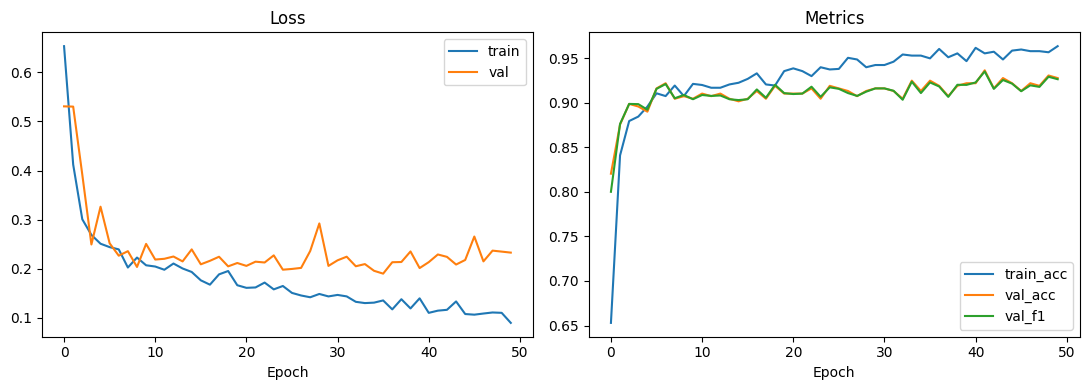

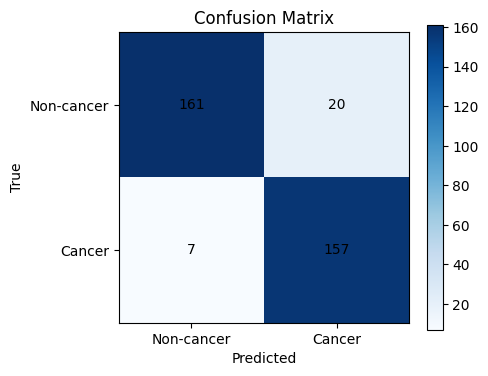

In [11]:
if TORCH_READY:
    plot_training_history(fusion_history, save_path=FIGURE_DIR / "fusion_training_history.png");
    plot_confusion_matrix(
        fusion_metrics["confusion_matrix"],
        class_names=["Non-cancer", "Cancer"],
        save_path=FIGURE_DIR / "fusion_confusion_matrix.png",
    );

#### 6.4.6 六分类细粒度识别实验

二分类模型用于先判断是否存在皮肤癌风险；六分类模型进一步识别具体病变类别。六分类标签顺序为 `ACK / BCC / MEL / NEV / SCC / SEK`。由于 `MEL` 和 `SCC` 样本较少，Macro F1、逐类 report 和混淆矩阵比单纯 Accuracy 更能反映模型对少数类和易混淆类别的表现。


In [12]:
if TORCH_READY:
    six_fusion_model, six_fusion_history = fit_model(
        six_fusion_model,
        six_train_loader,
        six_val_loader,
        num_epochs=EPOCHS,
        lr=1e-4,
        class_weights=six_class_weights,
        device=device,
    )
    torch.save(six_fusion_model.state_dict(), MODEL_DIR / "efficientnet_mlp_fusion_six_class.pt")
    six_metrics = evaluate(
        six_fusion_model,
        six_test_loader,
        torch.nn.CrossEntropyLoss(weight=six_class_weights.to(device)),
        device,
        class_names=DISEASE_CLASSES,
    )
    print("EfficientNet-MLP 六分类模型测试集结果：")
    print({k: round(v, 4) for k, v in six_metrics.items() if k in ["accuracy", "precision", "recall", "f1", "auc"]})
    print(six_metrics["classification_report"])

Epoch 1/50 | train_loss=1.7997 val_loss=1.7614 val_acc=0.5420 val_f1=0.2858
Epoch 2/50 | train_loss=1.7230 val_loss=1.6340 val_acc=0.4986 val_f1=0.3498
Epoch 3/50 | train_loss=1.5475 val_loss=1.4796 val_acc=0.4783 val_f1=0.2700
Epoch 4/50 | train_loss=1.3274 val_loss=1.2712 val_acc=0.6319 val_f1=0.4405
Epoch 5/50 | train_loss=1.2117 val_loss=1.0843 val_acc=0.6986 val_f1=0.5722
Epoch 6/50 | train_loss=1.0999 val_loss=0.9986 val_acc=0.4986 val_f1=0.4625
Epoch 7/50 | train_loss=0.9839 val_loss=1.0088 val_acc=0.7449 val_f1=0.6361
Epoch 8/50 | train_loss=0.9153 val_loss=0.8627 val_acc=0.6348 val_f1=0.6323
Epoch 9/50 | train_loss=0.8485 val_loss=0.8792 val_acc=0.7101 val_f1=0.6501
Epoch 10/50 | train_loss=0.8105 val_loss=0.7668 val_acc=0.7420 val_f1=0.6705
Epoch 11/50 | train_loss=0.8003 val_loss=0.8366 val_acc=0.6609 val_f1=0.6334
Epoch 12/50 | train_loss=0.7780 val_loss=0.7243 val_acc=0.7507 val_f1=0.6799
Epoch 13/50 | train_loss=0.7887 val_loss=0.7537 val_acc=0.7449 val_f1=0.6617
Epoch 14

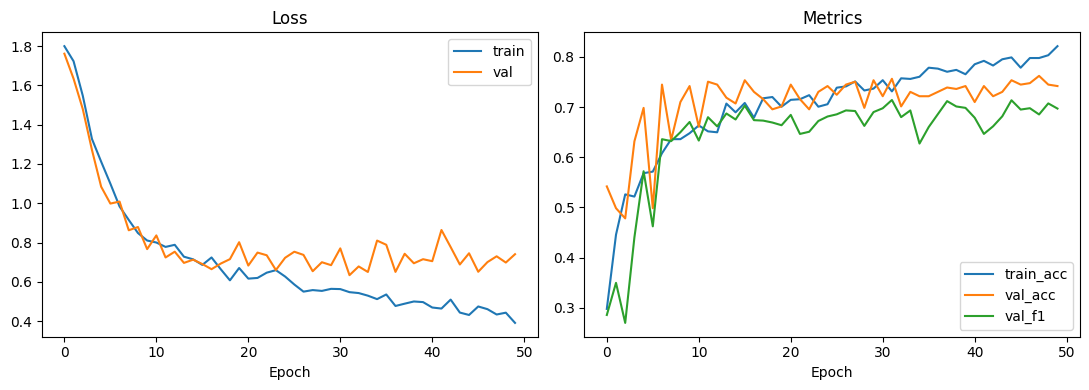

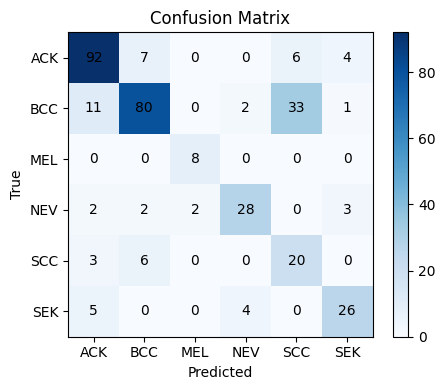

In [13]:
if TORCH_READY:
    plot_training_history(six_fusion_history, save_path=FIGURE_DIR / "six_class_training_history.png");
    plot_confusion_matrix(
        six_metrics["confusion_matrix"],
        class_names=DISEASE_CLASSES,
        save_path=FIGURE_DIR / "six_class_confusion_matrix.png",
    );

#### 6.4.7 六分类结果分析

六分类融合模型在测试集上取得 Accuracy 73.62%、Macro Precision 73.06%、Macro Recall 77.72%、Macro F1 73.92%、Macro AUC 95.50%。从逐类结果看，`ACK`、`MEL`、`NEV`、`SEK` 的 F1 分别为 0.83、0.89、0.79、0.75，表现相对较好；`BCC` 的 Precision 为 0.84、Recall 为 0.63，说明模型对 BCC 预测较谨慎，存在一部分 BCC 被分到其他类别；`SCC` 的 Precision 仅 0.34、F1 为 0.45，是当前六分类阶段的主要短板。

需要注意的是，`MEL` 测试集支持数只有 8 条，虽然本次 Recall 达到 1.00、F1 达到 0.89，但样本量过小，结论稳定性有限。整体来看，六分类模型已经能提供有参考价值的细粒度判断，但在少数类和形态相近类别之间仍需结合混淆矩阵、Grad-CAM 和临床信息进行人工复核。


In [18]:
pip install ipywidgets

### 6.5 可视化分析

#### 6.5.1 Grad-CAM 图像解释

本节展示模型可解释性和辅助诊断输出，包括 Grad-CAM 图像热力图、SHAP 表格特征解释以及 RAG-Agent 报告。Grad-CAM 用于观察图像分支在预测时主要关注哪些区域，从而判断模型是否聚焦于病灶及其边界、颜色和纹理变化。

展示样本由 `src.demo_utils.select_demo_sample()` 自动选取。本次运行选中测试集 `index=208`，图像为 `PAT_257_396_494.png`，真实类别为 `BCC`，二分类标签为 1；二分类和六分类均预测正确。该样本被用于 Grad-CAM、SHAP/RAG 解释和最终辅助诊断报告，保证不同解释模块围绕同一个病例展开。


展示样本 index=208
img_id=PAT_257_396_494.png, 真实类别=BCC, 二分类标签=1
二分类预测正确=True, 六分类预测正确=True
选取说明：满足指定类别 BCC，且二分类与六分类均预测正确；优先选择融合模型置信度较高的样本。


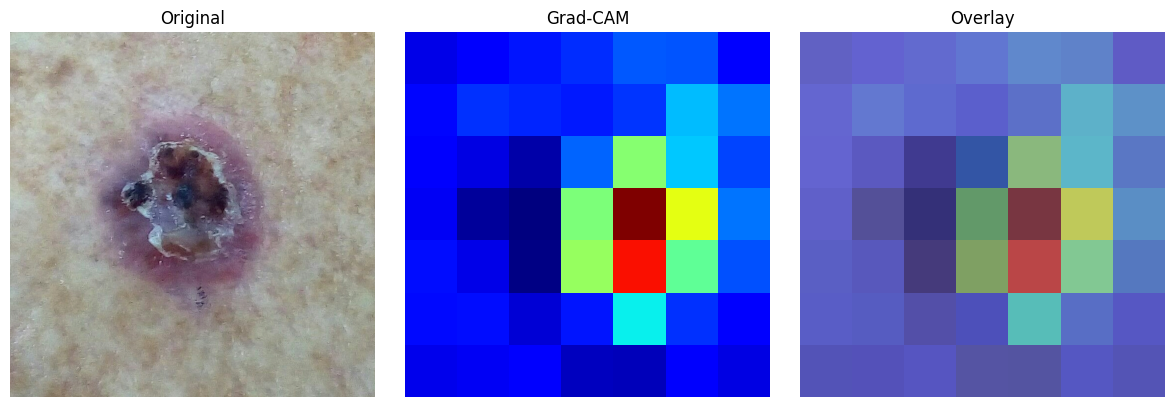

In [14]:
if TORCH_READY:
    import importlib
    import src.demo_utils as demo_utils_module

    importlib.reload(demo_utils_module)
    from src.demo_utils import ensure_test_metrics, select_demo_sample
    from src.explain import GradCAM, overlay_gradcam

    fusion_metrics, six_metrics = ensure_test_metrics(
        fusion_model,
        six_fusion_model,
        test_loader,
        six_test_loader,
        class_weights,
        six_class_weights,
        device,
        fusion_metrics=globals().get("fusion_metrics"),
        six_metrics=globals().get("six_metrics"),
    )

    demo_selection = select_demo_sample(
        test_run_df,
        fusion_metrics,
        six_metrics,
        DISEASE_CLASSES,
        prefer_diagnostic="BCC",
        require_binary_correct=True,
        require_six_class_correct=True,
    )
    demo_sample_index = demo_selection.index
    sample_row = test_run_df.iloc[demo_sample_index]

    sample = binary_test_dataset[demo_sample_index]
    image_tensor = sample["image"].unsqueeze(0).to(device)
    tabular_tensor = sample["tabular"].unsqueeze(0).to(device)

    # EfficientNet-B0 的最后一个特征块适合作为 Grad-CAM 目标层。
    target_layer = fusion_model.image_backbone.features[-1]
    gradcam = GradCAM(fusion_model, target_layer)
    heatmap = gradcam(image_tensor, tabular_tensor)
    gradcam.remove_hooks()

    gradcam_summary = (
        f"Grad-CAM 热力图显示模型对 img_id={demo_selection.img_id} 样本进行分类时，"
        f"主要关注病变区域及其边界、颜色与纹理变化。"
    )
    overlay_gradcam(
        sample_row["image_path"],
        heatmap,
        save_path=FIGURE_DIR / "gradcam_overlay.png",
    )
    print(f"展示样本 index={demo_sample_index}")
    print(f"img_id={demo_selection.img_id}, 真实类别={demo_selection.diagnostic}, 二分类标签={demo_selection.binary_label}")
    print(f"二分类预测正确={demo_selection.binary_correct}, 六分类预测正确={demo_selection.six_class_correct}")
    print(f"选取说明：{demo_selection.selection_reason}")

#### 6.5.2 SHAP 表格特征解释

SHAP 用于解释表格特征对“皮肤癌高风险”预测概率的贡献。为控制运行时间，本项目使用表格 baseline 对编码后的临床特征进行 SHAP 分析，并提取贡献绝对值较大的特征供 RAG-Agent 使用。本次辅助诊断报告中涉及的关键表格因素包括 `biopsed_False`、`grew_TRUE`、`diameter_1`、`skin_cancer_history_True` 等，分别对应未活检、病变增大、病变直径较大和既往皮肤癌史等风险线索。

需要说明的是，SHAP 解释反映的是当前模型和当前样本下的特征贡献方向与大小，不能直接等同于医学因果关系；其作用是帮助人工复核模型是否利用了合理的临床信息。


In [19]:
shap_features = []
if TORCH_READY:
    try:
        import shap

        tabular_baseline.eval()

        def baseline_predict_proba(x):
            with torch.no_grad():
                tab = torch.tensor(x.astype("float32"), device=device)
                dummy_image = torch.zeros((len(x), 3, 224, 224), device=device)
                logits = tabular_baseline(dummy_image, tab)
                return torch.softmax(logits, dim=1).cpu().numpy()

        background = X_train_run[: min(40, len(X_train_run))]
        explain_samples = X_test_run[: min(5, len(X_test_run))]
        explainer = shap.Explainer(baseline_predict_proba, background, feature_names=tabular_feature_names)
        shap_values = explainer(explain_samples)

        values = shap_values.values
        if values.ndim == 3:
            values = values[:, :, 1]
        first_values = values[0]
        top_idx = np.argsort(np.abs(first_values))[::-1][:8]
        shap_features = [(tabular_feature_names[i], float(first_values[i])) for i in top_idx]
        pd.DataFrame(shap_features, columns=["feature", "shap_value"])
    except Exception as exc:
        print("SHAP 分析未运行成功，可安装或检查 shap 依赖后重试：", exc)

#### 6.5.3 RAG-Agent 辅助诊断报告生成

本地 RAG 知识库位于 **`data/rag/`**，包含 `knowledge.json` 与 `docs/*.md`，共 19 条皮肤病变和 PAD-UFES-20 相关知识，由 `src/rag_knowledge.py` 自动生成与加载。RAG 检索、千问 API 调用与报告整合封装在 `src/rag_agent.py` 的 `run_rag_agent_pipeline` 中；notebook 负责传入预测结果、Grad-CAM 摘要、SHAP 特征和样本信息并展示输出。

本次运行中，RAG 检索到的主要文档为“病史与高危因素”“病变直径与风险评估”“病理活检与确诊”。Agent 报告综合给出：二分类预测为皮肤癌高风险，概率约 0.999996；六分类最可能为 `BCC`，概率约 0.7048，次高为 `SCC`，概率约 0.2577。报告同时结合 Grad-CAM、SHAP 和知识库内容提示该病例应尽快进行皮肤科评估和病理确认。

该报告只用于课程设计展示和辅助筛查，不能替代专业医生诊断。


In [20]:
import importlib

for mod_name in list(sys.modules):
    if mod_name in {"src.rag_agent", "src.config", "src.demo_utils"}:
        del sys.modules[mod_name]

import src.rag_agent as rag_agent_module
importlib.reload(rag_agent_module)
from src.rag_agent import print_rag_agent_result, run_rag_agent_pipeline

if TORCH_READY:
    agent_result = run_rag_agent_pipeline(
        fusion_metrics=fusion_metrics,
        six_metrics=six_metrics,
        sample_row=sample_row,
        gradcam_summary=gradcam_summary,
        disease_classes=DISEASE_CLASSES,
        shap_features=shap_features,
        env_path=PROJECT_ROOT / ".env",
        sample_index=demo_sample_index,
    )
    print_rag_agent_result(agent_result)

本地 RAG 知识库：E:\BDC_DL\data\rag\knowledge.json
调用千问 API：model=qwen-plus, base=https://dashscope.aliyuncs.com/compatible-mode/v1
【两阶段预测结果】
第一阶段二分类预测：皮肤癌高风险
二分类概率： {'非皮肤癌': 3.7280683500284795e-06, '皮肤癌': 0.9999963045120239}
第二阶段六分类预测：BCC
六分类概率： {'ACK': 0.003071734681725502, 'BCC': 0.7048183679580688, 'MEL': 0.006317242980003357, 'NEV': 0.0021581666078418493, 'SCC': 0.2576761841773987, 'SEK': 0.025958310812711716}

【RAG 检索文档】
- 病史与高危因素（相似度 0.454）
- 病变直径与风险评估（相似度 0.208）
- 病理活检与确诊（相似度 0.143）

【千问 Agent 生成的辅助诊断报告】
**皮肤病变辅助诊断报告**

1. **综合预测结论**  
模型高度提示该病变为皮肤恶性肿瘤，二分类结果明确指向“皮肤癌”（概率 1.000），六分类细粒度预测最可能为基底细胞癌（BCC），概率为 0.705；其余良性和其他恶性类别（如ACK、NEV、MEL、SCC、SEK）概率均低于 0.26，其中鳞状细胞癌（SCC）次高（0.258），但显著低于BCC。结合真实标签为BCC，模型预测与金标准一致。

2. **模型依据说明**  
- **图像依据**：Grad-CAM热力图显示模型决策聚焦于病变区域及其边界、颜色与纹理变化，符合BCC典型影像特征（如边缘不规则、表面毛细血管扩张、浅表溃疡或蜡样光泽）。  
- **临床表格特征依据**：SHAP分析表明，“未活检（biopsed_False）”“病变增大（grew_TRUE）”“直径较大（diameter_1）”“有皮肤癌病史（skin_cancer_history_True）”等关键风险因素对高风险预测贡献显著，与BCC的临床高危特征吻合（高龄、既往皮肤癌史、进行性生长）。  
- **医学知识支持*

#### 6.5.4 总结与心得

本课设围绕 PAD-UFES-20 数据集完成了皮肤病变多模态智能诊断系统设计，实现了从数据读取、预处理、模型训练、指标评估、可解释性分析到 RAG-Agent 报告生成的完整流程。实验结果表明，临床表格特征在本数据集上具有很强的皮肤癌风险判别能力，表格 MLP baseline 在二分类测试集上取得 94.49% Accuracy、94.29% F1 和 97.61% AUC；EfficientNet-MLP 融合模型取得 92.17% Accuracy、92.08% F1 和 96.83% AUC，并保持 95.73% 的皮肤癌召回率。六分类模型取得 73.62% Accuracy、73.92% Macro F1 和 95.50% Macro AUC，说明模型已具备一定细粒度识别能力，但 `SCC` 等类别仍存在明显混淆。

从实验分析看，多模态融合相比纯图像 baseline 有显著提升，但当前简单拼接融合尚未超过纯表格 baseline，说明图像分支仍有改进空间。后续可从使用 ImageNet 预训练、优化类别不平衡策略、保存验证集最优模型、引入注意力/门控融合机制和扩充数据增强等方向提升性能。

本项目的主要收获包括：掌握图像与表格数据匹配和编码方法，理解 EfficientNet 与 MLP 的多模态融合流程，熟悉二分类与多分类评价指标分析，并完成 Grad-CAM、SHAP、RAG 和 Agent 报告生成的集成。系统输出仅用于课程设计和辅助筛查展示，实际医学诊断仍需由专业医生结合面诊、皮肤镜和病理检查完成。
